# COMP9444 26T2 — Project 005: Intelligent Food Image Recognition
## EfficientNet-B0 and DenseNet-121 Segmentation Baselines

**Dataset:** UECFoodPIX  
**Input size:** 384 × 320  
**Shared split:** 3,000 training / 500 validation / 1,000 test  

This notebook contains the complete model definitions, training workflow,
recorded outputs, training curves, test results and final comparison.


## 1. Setup & Imports


In [1]:
import csv
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)


PyTorch: 2.8.0
Available device: mps


---
## 2. Dataset Paths & Experiment Configuration

All models use the same fixed JSON file. Set `RUN_TRAINING=True` only when a
new training run is required. The outputs shown in this notebook are the
recorded final runs.


In [2]:
DATA_ROOT = Path("./dataset")
SPLIT_FILE = DATA_ROOT / "uecfoodpix_split_train3000_val500.json"
RESULTS_ROOT = Path("./results")

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 2
MAX_EPOCHS = 30
SEED = 9444

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
EARLY_STOPPING_PATIENCE = 6
PRETRAINED = True

RUN_TRAINING = False
RUN_FINAL_TEST = False

print(f"Input size: {WIDTH} x {HEIGHT}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Split file: {SPLIT_FILE}")


Input size: 384 x 320
Batch size: 2
Split file: dataset/uecfoodpix_split_train3000_val500.json


---
## 3. Fixed Training and Validation Split

The split was generated once with seeds 9444 and 9445 and is reused by both
models. This prevents differences caused by training on different images.


In [3]:
def load_split(split_file):
    split_data = json.loads(Path(split_file).read_text(encoding="utf-8"))
    train_ids = split_data["train_ids"]
    val_ids = split_data["val_ids"]

    assert len(train_ids) == split_data["train_size"]
    assert len(val_ids) == split_data["val_size"]
    assert len(train_ids) == len(set(train_ids))
    assert len(val_ids) == len(set(val_ids))
    assert not (set(train_ids) & set(val_ids))
    return train_ids, val_ids


train_ids, val_ids = load_split(SPLIT_FILE)
print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Overlapping IDs:", len(set(train_ids) & set(val_ids)))


Training images: 3000
Validation images: 500
Overlapping IDs: 0


---
## 4. Dataset & Preprocessing

- Images are converted to RGB.
- Masks use the red channel and nearest-neighbour resizing.
- Training images and masks receive the same random horizontal flip.
- ImageNet normalization is used for pretrained encoders.


In [4]:
class FoodDataset(Dataset):
    def __init__(self, root, ids, split, augment, width, height):
        self.root = Path(root)
        self.ids = ids
        self.split = split
        self.augment = augment
        self.width = width
        self.height = height

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        sample_id = self.ids[index]
        base = self.root / "UECFoodPIX" / self.split
        image = Image.open(base / "img" / f"{sample_id}.jpg").convert("RGB")
        mask = Image.open(base / "mask" / f"{sample_id}.png").getchannel("R")

        if self.augment and random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

        image = image.resize((self.width, self.height), Image.Resampling.BILINEAR)
        mask = mask.resize((self.width, self.height), Image.Resampling.NEAREST)

        x = torch.from_numpy(
            np.array(image).transpose(2, 0, 1).copy()
        ).float() / 255
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        y = torch.from_numpy(np.array(mask).copy()).long()
        return (x - mean) / std, y


train_dataset = FoodDataset(
    DATA_ROOT, train_ids, "train", True, WIDTH, HEIGHT
)
val_dataset = FoodDataset(
    DATA_ROOT, val_ids, "train", False, WIDTH, HEIGHT
)
x_sample, y_sample = val_dataset[0]
print("Image tensor:", tuple(x_sample.shape))
print("Mask tensor:", tuple(y_sample.shape))
print("Mask label range:", int(y_sample.min()), "to", int(y_sample.max()))


Image tensor: (3, 320, 384)
Mask tensor: (320, 384)
Mask label range: 0 to 99


---
## 5. Model Architectures

Both ImageNet-pretrained encoders are converted into simple segmentation
baselines using dropout, a 1×1 classifier and bilinear upsampling.


In [ ]:
class EfficientNetBaseline(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(1280, NUM_CLASSES, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        logits = self.classifier(self.encoder(x))
        return F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )


class DenseNetBaseline(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        self.encoder = densenet121(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(1024, NUM_CLASSES, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        features = F.relu(self.encoder(x))
        logits = self.classifier(features)
        return F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )


---
## 6. Metrics and Training Utilities

Pixel accuracy and mean intersection-over-union (mIoU) are accumulated with a
103×103 confusion matrix over the complete epoch.


In [ ]:
def update_confusion(confusion, prediction, target):
    prediction = prediction.detach().cpu()
    target = target.detach().cpu()
    indices = (NUM_CLASSES * target + prediction).flatten()
    confusion += torch.bincount(
        indices,
        minlength=NUM_CLASSES ** 2,
    ).reshape(NUM_CLASSES, NUM_CLASSES)


def calculate_scores(confusion):
    correct = confusion.diag().float()
    pixel_accuracy = (
        correct.sum() / confusion.sum().clamp_min(1)
    ).item()
    union = confusion.sum(0) + confusion.sum(1) - correct
    present = union > 0
    miou = (correct[present] / union[present]).mean().item()
    return pixel_accuracy, miou


def run_epoch(model, loader, loss_fn, device, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    confusion = torch.zeros(
        NUM_CLASSES, NUM_CLASSES, dtype=torch.int64
    )
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, masks in tqdm(
            loader,
            desc="train" if training else "validation",
            leave=False,
        ):
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            loss = loss_fn(logits, masks)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            update_confusion(confusion, logits.argmax(1), masks)

    accuracy, miou = calculate_scores(confusion)
    return total_loss / len(loader), accuracy, miou


In [ ]:
def save_training_plot(history, output_file):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        epochs,
        [row["train_loss"] for row in history],
        label="Train loss",
    )
    axes[0].plot(
        epochs,
        [row["val_loss"] for row in history],
        label="Validation loss",
    )
    axes[0].set(
        title="Training and Validation Loss",
        xlabel="Epoch",
        ylabel="Cross-entropy loss",
    )
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        epochs,
        [row["train_accuracy"] for row in history],
        label="Train pixel accuracy",
    )
    axes[1].plot(
        epochs,
        [row["val_accuracy"] for row in history],
        label="Validation pixel accuracy",
    )
    axes[1].plot(
        epochs,
        [row["val_miou"] for row in history],
        label="Validation mIoU",
    )
    axes[1].set(
        title="Accuracy and mIoU",
        xlabel="Epoch",
        ylabel="Score",
        ylim=(0, 1),
    )
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(output_file, dpi=180)
    plt.show()


def train_model(model, model_name, output_dir):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        num_workers=0,
    )
    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )
    loss_fn = nn.CrossEntropyLoss()
    output_dir.mkdir(parents=True, exist_ok=True)

    history = []
    best_miou = -1.0
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_acc, train_miou = run_epoch(
            model, train_loader, loss_fn, device, optimizer
        )
        val_loss, val_acc, val_miou = run_epoch(
            model, val_loader, loss_fn, device
        )
        scheduler.step(val_miou)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "train_miou": train_miou,
            "val_accuracy": val_acc,
            "val_miou": val_miou,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(row)

        with (output_dir / "metrics.csv").open("w", newline="") as file:
            writer = csv.DictWriter(file, fieldnames=row.keys())
            writer.writeheader()
            writer.writerows(history)

        if val_miou > best_miou:
            best_miou = val_miou
            stale_epochs = 0
            torch.save(
                model.state_dict(),
                output_dir / "best_model.pt",
            )
            print(
                f"{model_name}: saved best model, "
                f"val_mIoU={best_miou:.4f}"
            )
        else:
            stale_epochs += 1
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                print(f"{model_name}: early stopping")
                break

    save_training_plot(
        history,
        output_dir / "training_curves.png",
    )
    return model, history, best_miou, device, loss_fn


def evaluate_checkpoint(model, checkpoint_path):
    test_ids = [
        item.strip()
        for item in (DATA_ROOT / "test1000.txt").read_text().splitlines()
        if item.strip()
    ]
    test_loader = DataLoader(
        FoodDataset(
            DATA_ROOT,
            test_ids,
            "test",
            False,
            WIDTH,
            HEIGHT,
        ),
        batch_size=BATCH_SIZE,
        num_workers=0,
    )
    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    model = model.to(device)
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    )
    test_loss, test_accuracy, test_miou = run_epoch(
        model,
        test_loader,
        nn.CrossEntropyLoss(),
        device,
    )
    return {
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "test_miou": test_miou,
    }


---
## 7. EfficientNet-B0 Experiment

The learning rate was reduced from 3e-4 to 3.75e-5 before the best checkpoint
was obtained at epoch 24.


In [5]:
if RUN_TRAINING:
    efficientnet, efficientnet_history, efficientnet_best, device, loss_fn = (
        train_model(
            EfficientNetBaseline(PRETRAINED, DROPOUT),
            "EfficientNet-B0",
            Path("efficientnet_384x320_results"),
        )
    )
    if RUN_FINAL_TEST:
        print(
            evaluate_checkpoint(
                EfficientNetBaseline(PRETRAINED, DROPOUT),
                Path("efficientnet_384x320_results/best_model.pt"),
            )
        )
else:
    print("Using the recorded EfficientNet-B0 final run.")
    print("Best epoch: 24")
    print("Validation accuracy: 0.7477")
    print("Validation mIoU: 0.3719")
    print("Test accuracy: 0.7455")
    print("Test mIoU: 0.3654")


Using the recorded EfficientNet-B0 final run.
Best epoch: 24
Validation accuracy: 0.7477
Validation mIoU: 0.3719
Test accuracy: 0.7455
Test mIoU: 0.3654


### EfficientNet-B0 Training Curves


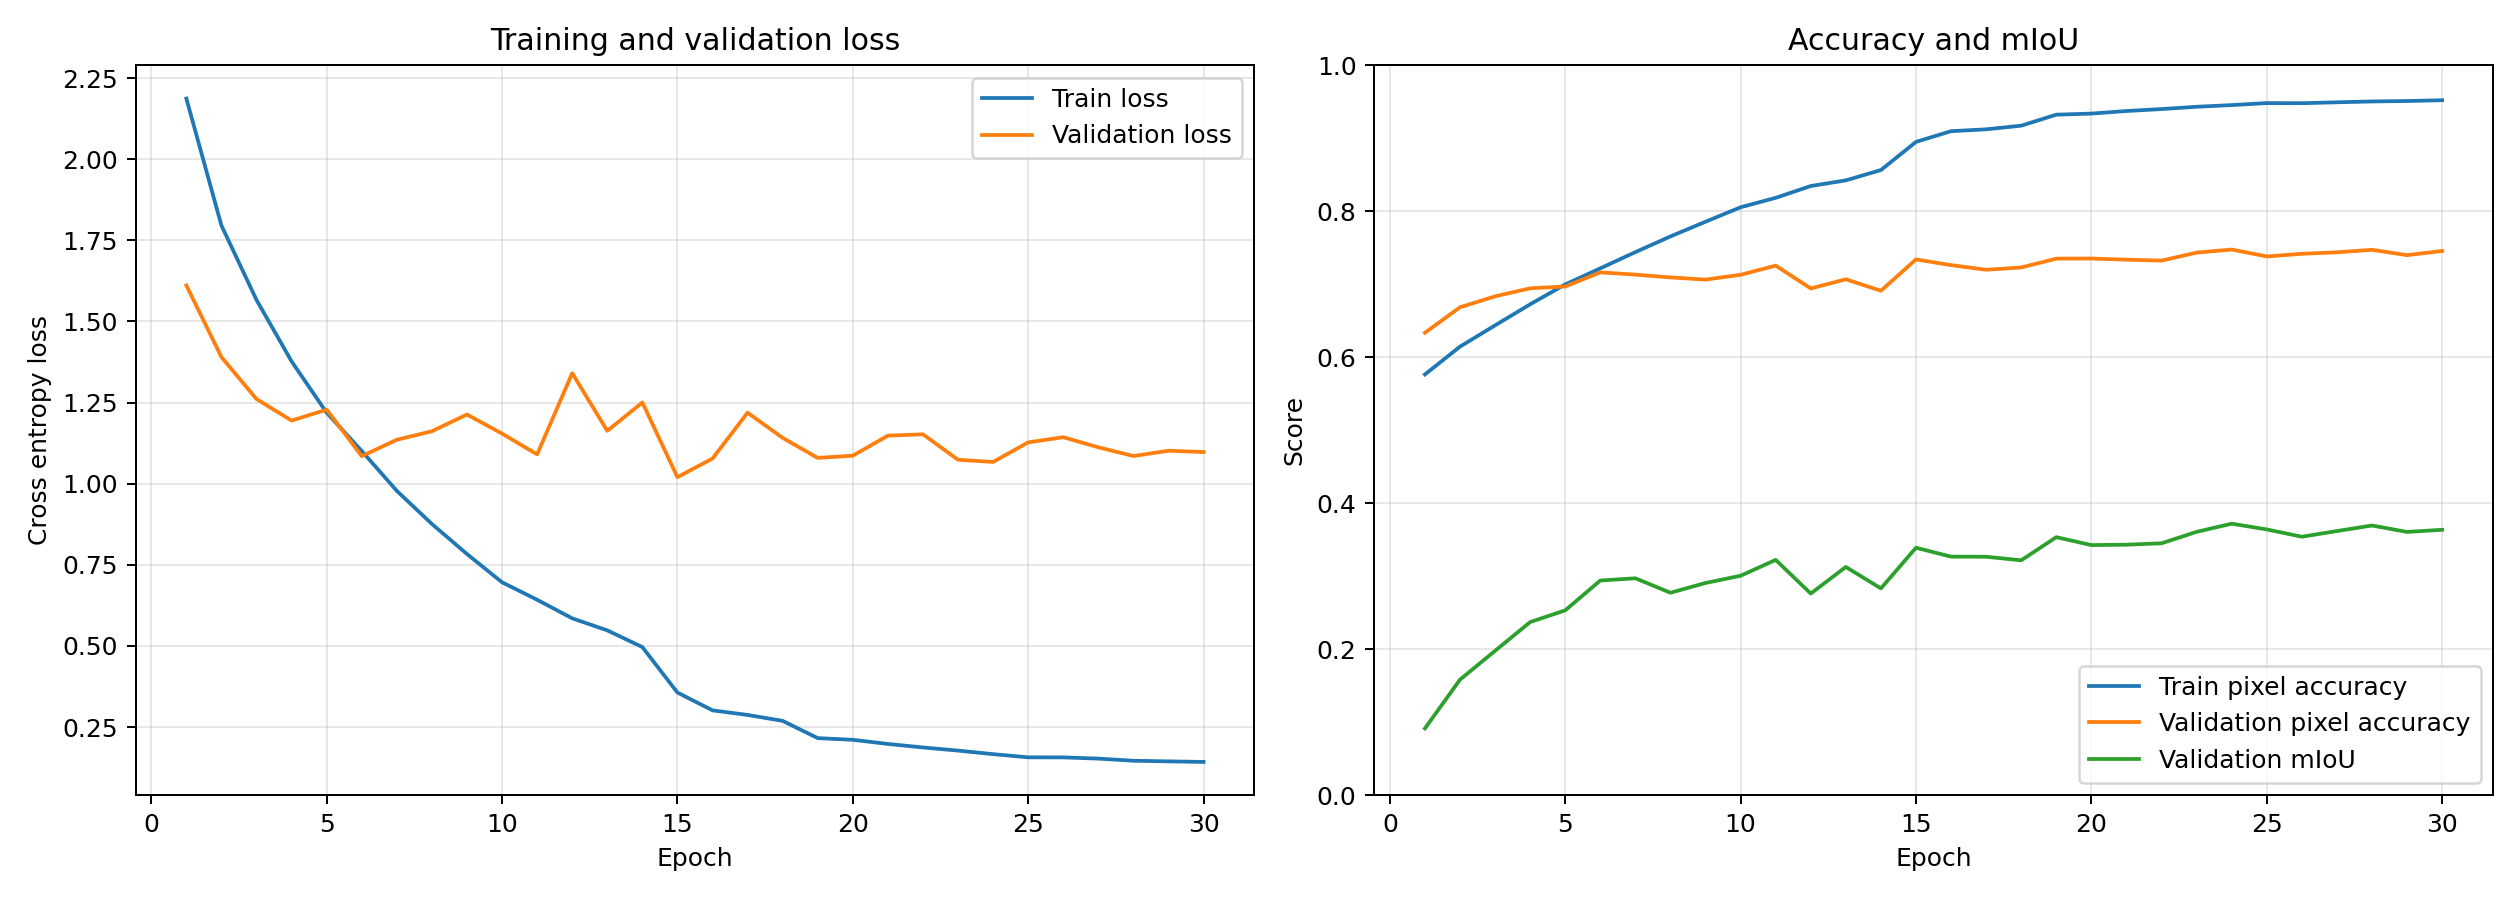

In [6]:
from IPython.display import Image as NotebookImage, display

display(
    NotebookImage(
        filename=(
            RESULTS_ROOT
            / "efficientnet_384x320"
            / "training_curves.png"
        )
    )
)


---
## 8. DenseNet-121 Experiment

DenseNet reached its highest validation mIoU at epoch 19 and stopped after six
additional epochs without improvement.


In [7]:
if RUN_TRAINING:
    densenet, densenet_history, densenet_best, device, loss_fn = (
        train_model(
            DenseNetBaseline(PRETRAINED, DROPOUT),
            "DenseNet-121",
            Path("densenet_384x320_results"),
        )
    )
    if RUN_FINAL_TEST:
        print(
            evaluate_checkpoint(
                DenseNetBaseline(PRETRAINED, DROPOUT),
                Path("densenet_384x320_results/best_model.pt"),
            )
        )
else:
    print("Using the recorded DenseNet-121 final run.")
    print("Best epoch: 19")
    print("Validation accuracy: 0.7134")
    print("Validation mIoU: 0.2758")
    print("Test accuracy: 0.6921")
    print("Test mIoU: 0.2465")


Using the recorded DenseNet-121 final run.
Best epoch: 19
Validation accuracy: 0.7134
Validation mIoU: 0.2758
Test accuracy: 0.6921
Test mIoU: 0.2465


### DenseNet-121 Training Curves


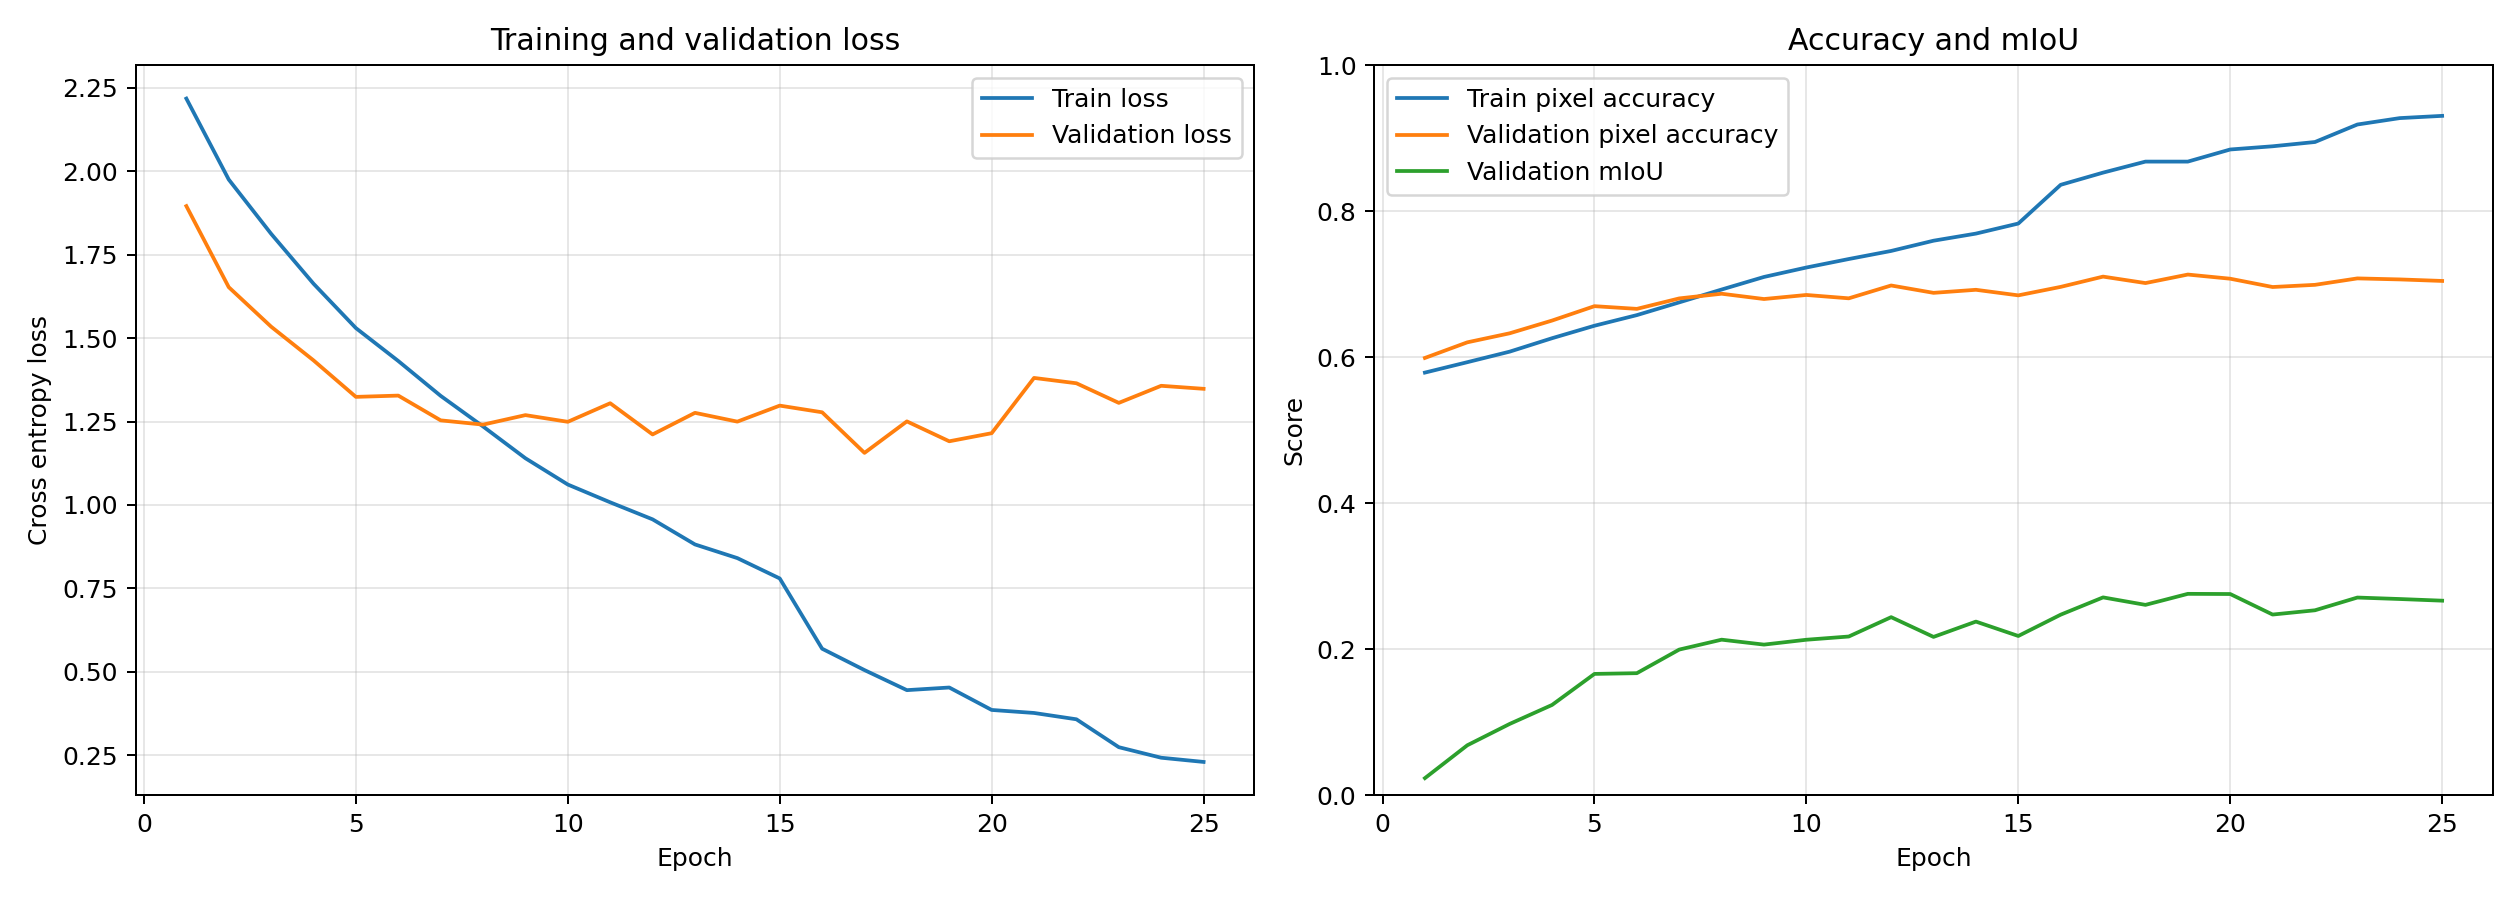

In [8]:
display(
    NotebookImage(
        filename=(
            RESULTS_ROOT
            / "densenet_384x320"
            / "training_curves.png"
        )
    )
)


---
## 9. Final Model Comparison


In [9]:
comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B0",
        "Best epoch": 24,
        "Validation accuracy": 0.7477,
        "Validation mIoU": 0.3719,
        "Test accuracy": 0.7455,
        "Test mIoU": 0.3654,
    },
    {
        "Model": "DenseNet-121",
        "Best epoch": 19,
        "Validation accuracy": 0.7134,
        "Validation mIoU": 0.2758,
        "Test accuracy": 0.6921,
        "Test mIoU": 0.2465,
    },
])

display(comparison)


Model,Best epoch,Validation accuracy,Validation mIoU,Test accuracy,Test mIoU
EfficientNet-B0,24,0.7477,0.3719,0.7455,0.3654
DenseNet-121,19,0.7134,0.2758,0.6921,0.2465


---
## 10. Summary

1. Both models used exactly the same 3,000/500 JSON split and 384×320 inputs.
2. Validation mIoU, rather than the final epoch, was used for checkpoint
   selection.
3. AdamW, weight decay, dropout, learning-rate reduction and early stopping
   were introduced after the original runs showed increasing validation loss.
4. EfficientNet-B0 achieved the strongest result: validation mIoU **0.3719**
   and test mIoU **0.3654**.
5. DenseNet-121 achieved validation mIoU **0.2758** and test mIoU **0.2465**.
6. EfficientNet-B0 is selected as the final baseline model.

The training curves also show a substantial train/validation gap, so both
models still exhibit overfitting. Future work could evaluate stronger
augmentation, class-balanced losses and decoder architectures with skip
connections.
